# DSAI5207 Lecture 7 Lab: Neural Network Pruning and Quantization

This lab follows the lecture-style flow used in Lecture 6, but focuses on **model compression**.

## Learning goals
1. Build intuition for why pruning and quantization work.
2. Compare different pruning criteria: random, magnitude, and first-order saliency.
3. Visualize the pruning process step by step and inspect how masks modify weights.
4. Identify which layers and individual weights are most prunable.
5. Understand quantization levels and evaluate accuracy-memory tradeoffs.


## 1. Environment and Imports

In [1]:
import copy
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

plt.style.use("seaborn-v0_8-whitegrid")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


def set_seed(seed=5207):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(5207)


Using device: cuda


## 2. Create a Simple 2D Classification Dataset

We use a small two-moons-style dataset so that every compression step can be visualized clearly.

Train/Val/Test sizes: 1800/600/600


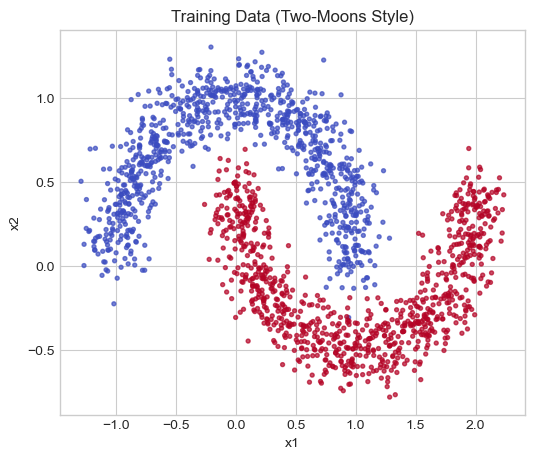

In [2]:
def make_two_moons(n_samples=3000, noise=0.10, seed=5207):
    rng = np.random.default_rng(seed)
    n1 = n_samples // 2
    n2 = n_samples - n1

    theta1 = rng.uniform(0.0, np.pi, n1)
    theta2 = rng.uniform(0.0, np.pi, n2)

    moon1 = np.c_[np.cos(theta1), np.sin(theta1)]
    moon2 = np.c_[1.0 - np.cos(theta2), 1.0 - np.sin(theta2) - 0.5]

    X = np.vstack([moon1, moon2])
    y = np.hstack([
        np.zeros(n1, dtype=np.int64),
        np.ones(n2, dtype=np.int64)
    ])

    X += rng.normal(scale=noise, size=X.shape)

    perm = rng.permutation(n_samples)
    return X[perm], y[perm]


X, y = make_two_moons(n_samples=3000, noise=0.12)

n_total = len(X)
n_train = int(0.6 * n_total)
n_val = int(0.2 * n_total)

X_train, y_train = X[:n_train], y[:n_train]
X_val, y_val = X[n_train:n_train + n_val], y[n_train:n_train + n_val]
X_test, y_test = X[n_train + n_val:], y[n_train + n_val:]

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=128, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=256, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=256, shuffle=False)

print(f"Train/Val/Test sizes: {len(X_train_t)}/{len(X_val_t)}/{len(X_test_t)}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=8, cmap="coolwarm", alpha=0.7)
ax.set_title("Training Data (Two-Moons Style)")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
plt.show()


## 3. Baseline Model and Training Utilities

In [3]:
class TinyMLP(nn.Module):
    def __init__(self, hidden1=64, hidden2=64):
        super().__init__()
        self.fc1 = nn.Linear(2, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, 2)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)


def linear_layers(model):
    return {
        name: module
        for name, module in model.named_modules()
        if isinstance(module, nn.Linear)
    }


def evaluate(model, data_loader):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0

    with torch.no_grad():
        for xb, yb in data_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = F.cross_entropy(logits, yb)

            total_loss += loss.item() * xb.size(0)
            total_correct += (logits.argmax(dim=1) == yb).sum().item()
            total += xb.size(0)

    return total_loss / total, total_correct / total


def init_masks(model):
    masks = {}
    for name, layer in linear_layers(model).items():
        masks[name] = torch.ones_like(layer.weight.data, device=device)
    return masks


def apply_masks(model, masks):
    with torch.no_grad():
        for name, layer in linear_layers(model).items():
            if name in masks:
                layer.weight.data.mul_(masks[name])


def mask_gradients(model, masks):
    for name, layer in linear_layers(model).items():
        if name in masks and layer.weight.grad is not None:
            layer.weight.grad.mul_(masks[name])


def mask_sparsity_by_layer(masks):
    stats = {}
    for name, mask in masks.items():
        zero_frac = (mask.numel() - mask.sum().item()) / mask.numel()
        stats[name] = zero_frac
    return stats


def model_global_sparsity_from_masks(masks):
    total = 0
    zeros = 0
    for mask in masks.values():
        total += mask.numel()
        zeros += (mask.numel() - int(mask.sum().item()))
    return zeros / total


def train_model(model, train_loader, val_loader, epochs=80, lr=1e-2, masks=None, verbose_every=20):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        running_correct = 0
        total = 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = F.cross_entropy(logits, yb)
            loss.backward()

            if masks is not None:
                mask_gradients(model, masks)

            optimizer.step()

            if masks is not None:
                apply_masks(model, masks)

            running_loss += loss.item() * xb.size(0)
            running_correct += (logits.argmax(dim=1) == yb).sum().item()
            total += xb.size(0)

        train_loss = running_loss / total
        train_acc = running_correct / total
        val_loss, val_acc = evaluate(model, val_loader)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if verbose_every and (epoch == 1 or epoch % verbose_every == 0):
            print(
                f"Epoch {epoch:3d}/{epochs} | "
                f"train_loss={train_loss:.4f}, train_acc={train_acc:.3f}, "
                f"val_acc={val_acc:.3f}"
            )

    return history


def plot_decision_boundary(model, X_np, y_np, title="Decision Boundary", ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 5))

    x_min, x_max = X_np[:, 0].min() - 0.4, X_np[:, 0].max() + 0.4
    y_min, y_max = X_np[:, 1].min() - 0.4, X_np[:, 1].max() + 0.4

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 250),
        np.linspace(y_min, y_max, 250)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_t = torch.tensor(grid, dtype=torch.float32, device=device)

    model.eval()
    with torch.no_grad():
        zz = model(grid_t).argmax(dim=1).cpu().numpy().reshape(xx.shape)

    ax.contourf(xx, yy, zz, alpha=0.25, cmap="coolwarm")
    ax.scatter(X_np[:, 0], X_np[:, 1], c=y_np, s=10, cmap="coolwarm", edgecolors="none")
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")


Epoch   1/120 | train_loss=0.3600, train_acc=0.830, val_acc=0.897
Epoch  30/120 | train_loss=0.0060, train_acc=0.998, val_acc=0.998
Epoch  60/120 | train_loss=0.0064, train_acc=0.998, val_acc=0.998
Epoch  90/120 | train_loss=0.0097, train_acc=0.997, val_acc=0.997
Epoch 120/120 | train_loss=0.0045, train_acc=0.998, val_acc=0.995

Baseline test accuracy: 0.995


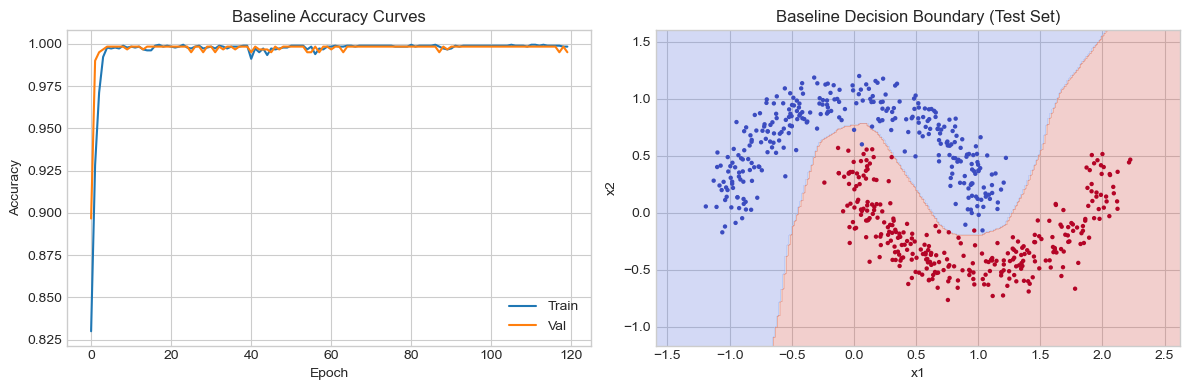

In [4]:
baseline_model = TinyMLP().to(device)
baseline_history = train_model(
    baseline_model,
    train_loader,
    val_loader,
    epochs=120,
    lr=1e-2,
    masks=None,
    verbose_every=30
)

baseline_test_loss, baseline_test_acc = evaluate(baseline_model, test_loader)
print(f"\nBaseline test accuracy: {baseline_test_acc:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(baseline_history["train_acc"], label="Train")
axes[0].plot(baseline_history["val_acc"], label="Val")
axes[0].set_title("Baseline Accuracy Curves")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

plot_decision_boundary(
    baseline_model,
    X_test,
    y_test,
    title="Baseline Decision Boundary (Test Set)",
    ax=axes[1]
)

plt.tight_layout()
plt.show()


## 4. Pruning Criteria: What Counts as "Unimportant"?

We will compare three criteria at the same target sparsity:
1. **Random**: a control baseline.
2. **Magnitude**: prune small absolute weights.
3. **First-order saliency**: prune small \(|w \cdot \partial L / \partial w|\), a sensitivity proxy.


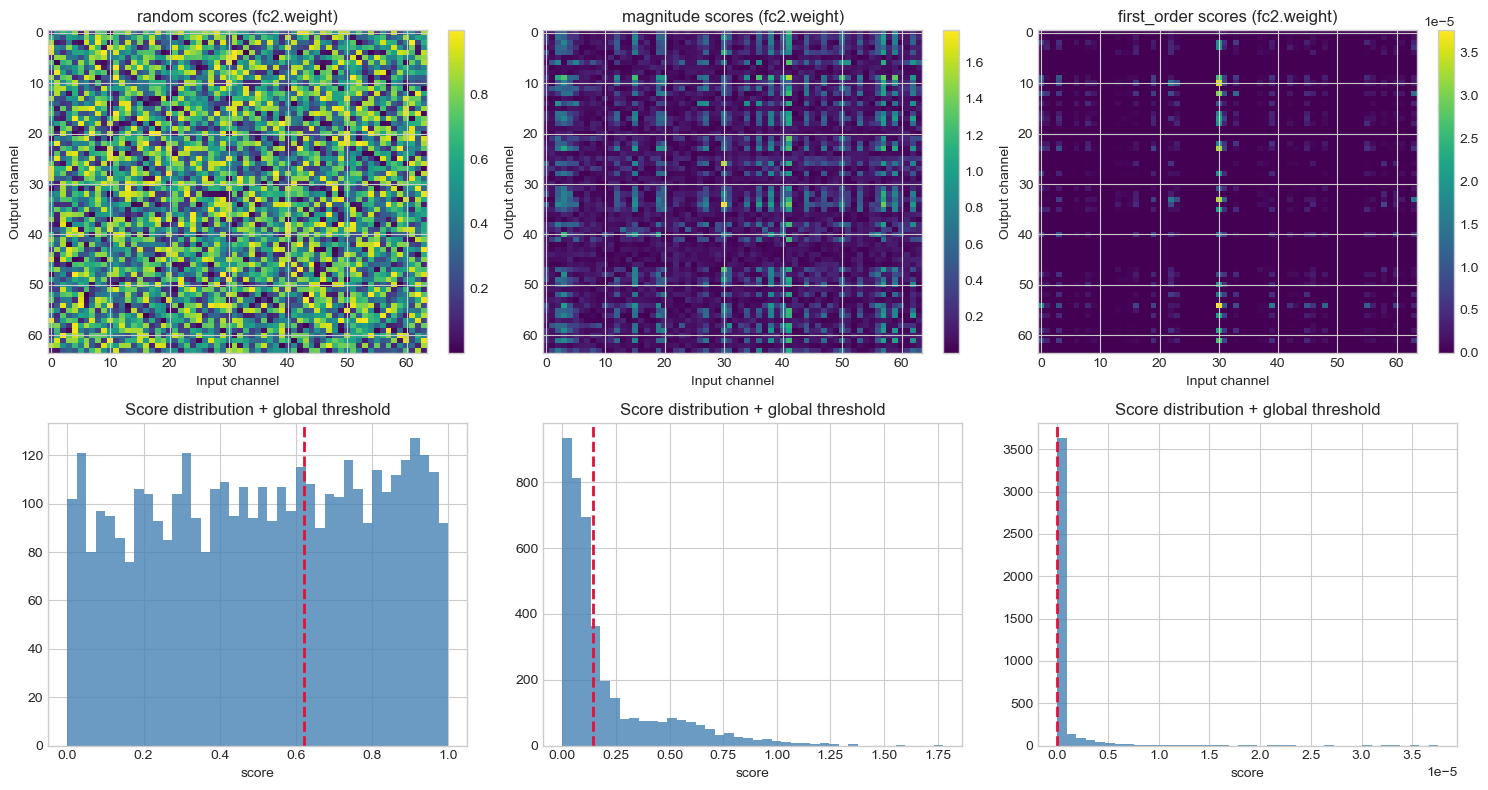

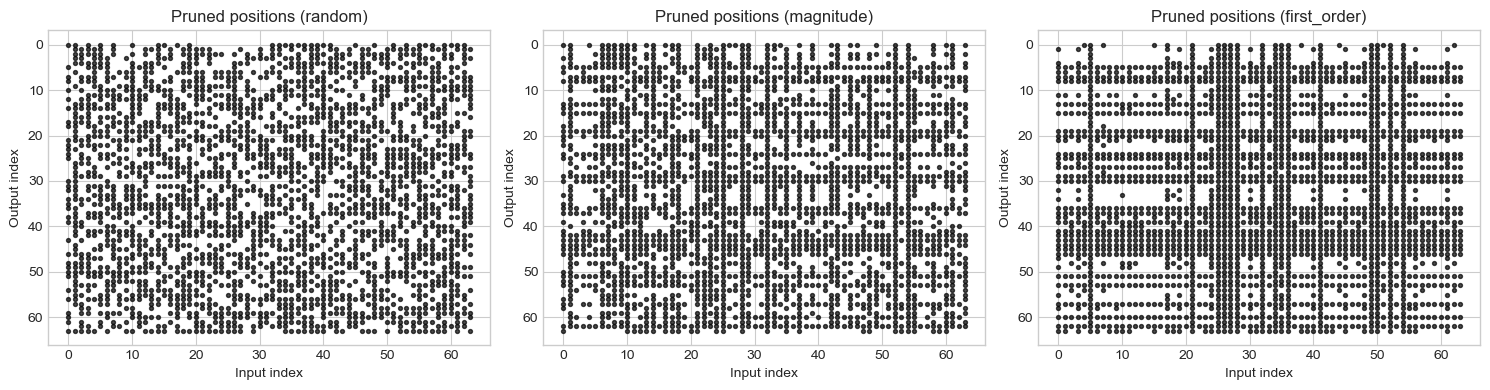

In [5]:
def get_one_batch(data_loader):
    xb, yb = next(iter(data_loader))
    return xb.to(device), yb.to(device)


def compute_pruning_scores(model, criterion="magnitude", batch=None):
    scores = {}

    if criterion == "first_order":
        if batch is None:
            raise ValueError("batch is required for first_order criterion")

        model.zero_grad(set_to_none=True)
        xb, yb = batch
        logits = model(xb)
        loss = F.cross_entropy(logits, yb)
        loss.backward()

    for name, layer in linear_layers(model).items():
        w = layer.weight.data

        if criterion == "random":
            s = torch.rand_like(w)
        elif criterion == "magnitude":
            s = w.abs()
        elif criterion == "first_order":
            grad = layer.weight.grad
            s = (w * grad).abs()
        else:
            raise ValueError(f"Unknown criterion: {criterion}")

        scores[name] = s.detach().clone()

    model.zero_grad(set_to_none=True)
    return scores


def build_global_mask_from_scores(scores, target_sparsity=0.6):
    flat = torch.cat([v.flatten() for v in scores.values()])
    total = flat.numel()

    n_keep = max(int(round((1.0 - target_sparsity) * total)), 1)
    n_keep = min(n_keep, total)

    threshold = torch.topk(flat, k=n_keep).values.min()
    masks = {name: (s >= threshold).float().to(device) for name, s in scores.items()}
    return masks, float(threshold.item())


criteria = ["random", "magnitude", "first_order"]
target_sparsity = 0.60
criteria_scores = {}
criteria_masks = {}
criteria_thresholds = {}

batch = get_one_batch(train_loader)
for criterion in criteria:
    scores = compute_pruning_scores(
        baseline_model,
        criterion=criterion,
        batch=batch if criterion == "first_order" else None
    )
    masks, threshold = build_global_mask_from_scores(scores, target_sparsity=target_sparsity)

    criteria_scores[criterion] = scores
    criteria_masks[criterion] = masks
    criteria_thresholds[criterion] = threshold

layer_name = "fc2"
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, criterion in enumerate(criteria):
    s = criteria_scores[criterion][layer_name].detach().cpu().numpy()

    im = axes[0, i].imshow(s, cmap="viridis", aspect="auto")
    axes[0, i].set_title(f"{criterion} scores ({layer_name}.weight)")
    axes[0, i].set_xlabel("Input channel")
    axes[0, i].set_ylabel("Output channel")
    plt.colorbar(im, ax=axes[0, i], fraction=0.046)

    axes[1, i].hist(s.ravel(), bins=40, color="steelblue", alpha=0.8)
    axes[1, i].axvline(criteria_thresholds[criterion], color="crimson", linestyle="--", linewidth=2)
    axes[1, i].set_title(f"Score distribution + global threshold")
    axes[1, i].set_xlabel("score")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, criterion in enumerate(criteria):
    mask = criteria_masks[criterion][layer_name].detach().cpu().numpy()
    pruned = np.argwhere(mask == 0)

    if len(pruned) > 0:
        axes[i].scatter(pruned[:, 1], pruned[:, 0], s=8, alpha=0.7, color="black")

    axes[i].set_title(f"Pruned positions ({criterion})")
    axes[i].set_xlabel("Input index")
    axes[i].set_ylabel("Output index")
    axes[i].invert_yaxis()

plt.tight_layout()
plt.show()


## 5. One-Shot Pruning Comparison (Same Sparsity, Different Criterion)

We apply each mask at 60% sparsity, check immediate accuracy drop, then briefly fine-tune while keeping pruned weights fixed.

    random | sparsity=0.60 | test_acc before FT=0.817 | after FT=0.997
 magnitude | sparsity=0.60 | test_acc before FT=0.993 | after FT=0.995
first_order | sparsity=0.60 | test_acc before FT=0.908 | after FT=0.995


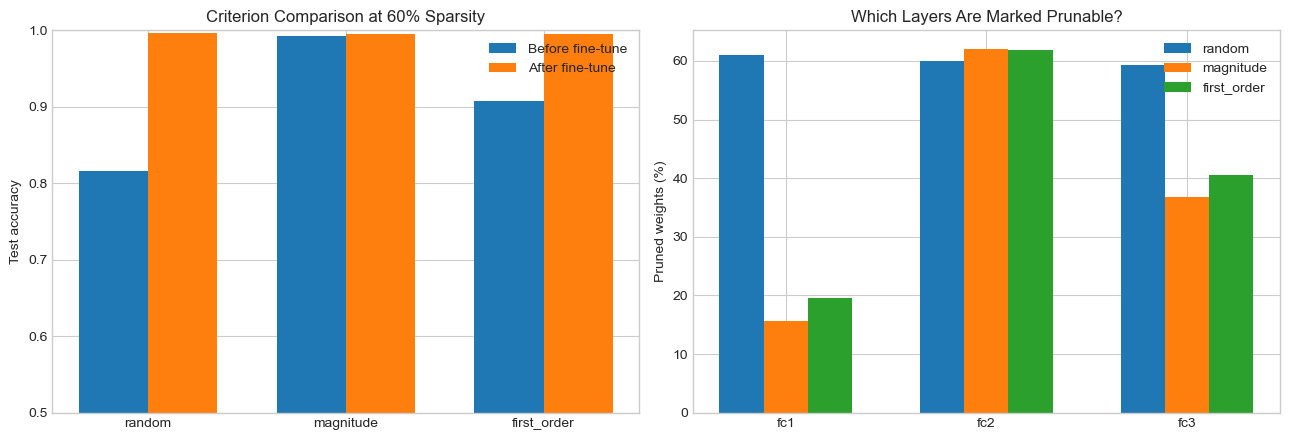

In [6]:
comparison_rows = []
criterion_layer_sparsity = {}

for criterion in criteria:
    model_c = copy.deepcopy(baseline_model).to(device)
    masks_c = {name: mask.clone().to(device) for name, mask in criteria_masks[criterion].items()}

    apply_masks(model_c, masks_c)
    _, acc_before = evaluate(model_c, test_loader)

    _ = train_model(
        model_c,
        train_loader,
        val_loader,
        epochs=30,
        lr=3e-3,
        masks=masks_c,
        verbose_every=0
    )

    _, acc_after = evaluate(model_c, test_loader)
    layer_sparse = mask_sparsity_by_layer(masks_c)
    criterion_layer_sparsity[criterion] = layer_sparse

    comparison_rows.append({
        "criterion": criterion,
        "acc_before_ft": acc_before,
        "acc_after_ft": acc_after,
        "global_sparsity": model_global_sparsity_from_masks(masks_c)
    })

for row in comparison_rows:
    print(
        f"{row['criterion']:>10s} | sparsity={row['global_sparsity']:.2f} "
        f"| test_acc before FT={row['acc_before_ft']:.3f} "
        f"| after FT={row['acc_after_ft']:.3f}"
    )

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

x = np.arange(len(criteria))
acc_before = [row["acc_before_ft"] for row in comparison_rows]
acc_after = [row["acc_after_ft"] for row in comparison_rows]

width = 0.35
axes[0].bar(x - width / 2, acc_before, width=width, label="Before fine-tune")
axes[0].bar(x + width / 2, acc_after, width=width, label="After fine-tune")
axes[0].set_xticks(x)
axes[0].set_xticklabels(criteria)
axes[0].set_ylim(0.5, 1.0)
axes[0].set_ylabel("Test accuracy")
axes[0].set_title("Criterion Comparison at 60% Sparsity")
axes[0].legend()

layers = list(linear_layers(baseline_model).keys())
bar_w = 0.22
for i, criterion in enumerate(criteria):
    vals = [criterion_layer_sparsity[criterion][layer] * 100.0 for layer in layers]
    axes[1].bar(np.arange(len(layers)) + i * bar_w, vals, width=bar_w, label=criterion)

axes[1].set_xticks(np.arange(len(layers)) + bar_w)
axes[1].set_xticklabels(layers)
axes[1].set_ylabel("Pruned weights (%)")
axes[1].set_title("Which Layers Are Marked Prunable?")
axes[1].legend()

plt.tight_layout()
plt.show()


## 6. Iterative Magnitude Pruning: Step-by-Step Process

Instead of pruning once, we prune gradually to increasing sparsity targets and fine-tune after each step.

Step 1 | target=0.20 | global_sparsity=0.200 | test_acc before=0.995, after=0.995
Step 2 | target=0.40 | global_sparsity=0.400 | test_acc before=0.995, after=0.995
Step 3 | target=0.60 | global_sparsity=0.600 | test_acc before=0.995, after=0.995
Step 4 | target=0.75 | global_sparsity=0.750 | test_acc before=0.993, after=0.995
Step 5 | target=0.85 | global_sparsity=0.850 | test_acc before=0.993, after=0.995


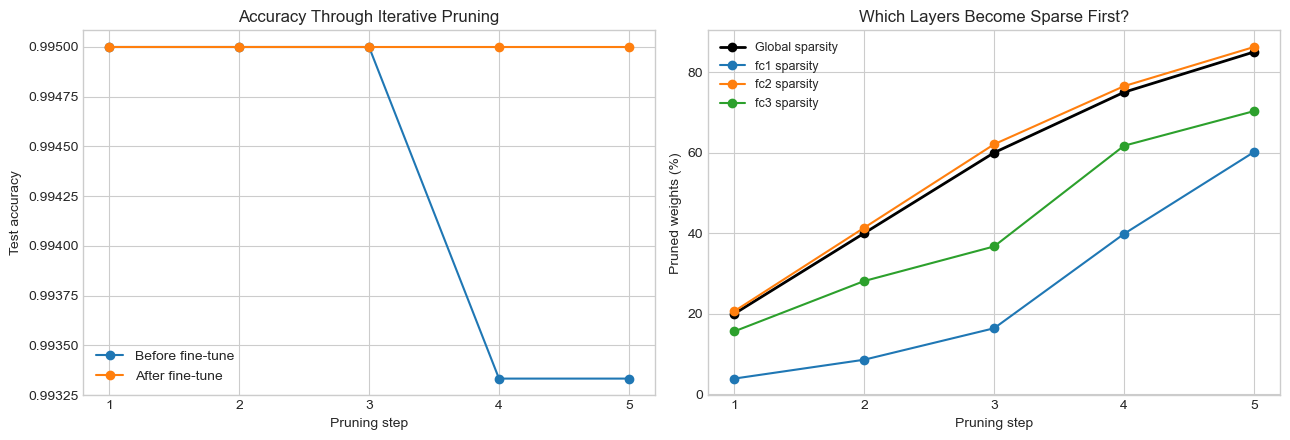

In [7]:
def prune_magnitude_to_target(model, masks, target_sparsity):
    layers = linear_layers(model)

    total = 0
    active_scores = []
    for name, layer in layers.items():
        mask = masks[name]
        w_abs = layer.weight.data.abs()

        total += mask.numel()
        current_active = w_abs[mask.bool()]
        if current_active.numel() > 0:
            active_scores.append(current_active.flatten())

    flat_active = torch.cat(active_scores)
    n_keep = max(int(round((1.0 - target_sparsity) * total)), 1)
    n_keep = min(n_keep, flat_active.numel())

    threshold = torch.topk(flat_active, k=n_keep).values.min()

    new_masks = {}
    for name, layer in layers.items():
        w_abs = layer.weight.data.abs()
        new_masks[name] = masks[name] * (w_abs >= threshold).float()

    return new_masks, float(threshold.item())


iter_model = copy.deepcopy(baseline_model).to(device)
iter_masks = init_masks(iter_model)
apply_masks(iter_model, iter_masks)

prune_schedule = [0.20, 0.40, 0.60, 0.75, 0.85]
iter_records = []

for step_id, target in enumerate(prune_schedule, start=1):
    iter_masks, threshold = prune_magnitude_to_target(iter_model, iter_masks, target_sparsity=target)
    apply_masks(iter_model, iter_masks)

    _, acc_before = evaluate(iter_model, test_loader)

    _ = train_model(
        iter_model,
        train_loader,
        val_loader,
        epochs=18,
        lr=2e-3,
        masks=iter_masks,
        verbose_every=0
    )

    _, acc_after = evaluate(iter_model, test_loader)

    layer_sparse = mask_sparsity_by_layer(iter_masks)
    global_sparse = model_global_sparsity_from_masks(iter_masks)

    iter_records.append({
        "step": step_id,
        "target": target,
        "threshold": threshold,
        "acc_before": acc_before,
        "acc_after": acc_after,
        "global_sparsity": global_sparse,
        "layer_sparsity": layer_sparse
    })

    print(
        f"Step {step_id} | target={target:.2f} | "
        f"global_sparsity={global_sparse:.3f} | "
        f"test_acc before={acc_before:.3f}, after={acc_after:.3f}"
    )

steps = [r["step"] for r in iter_records]
acc_before = [r["acc_before"] for r in iter_records]
acc_after = [r["acc_after"] for r in iter_records]
global_sparse = [r["global_sparsity"] for r in iter_records]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(steps, acc_before, marker="o", label="Before fine-tune")
axes[0].plot(steps, acc_after, marker="o", label="After fine-tune")
axes[0].set_xticks(steps)
axes[0].set_xlabel("Pruning step")
axes[0].set_ylabel("Test accuracy")
axes[0].set_title("Accuracy Through Iterative Pruning")
axes[0].legend()

axes[1].plot(steps, np.array(global_sparse) * 100, marker="o", color="black", linewidth=2, label="Global sparsity")
for layer in linear_layers(iter_model).keys():
    vals = [r["layer_sparsity"][layer] * 100 for r in iter_records]
    axes[1].plot(steps, vals, marker="o", label=f"{layer} sparsity")

axes[1].set_xticks(steps)
axes[1].set_xlabel("Pruning step")
axes[1].set_ylabel("Pruned weights (%)")
axes[1].set_title("Which Layers Become Sparse First?")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()


## 7. How Weights Are Modified by Pruning

Below we inspect one layer before pruning vs after iterative pruning. The mask explicitly zeroes selected weights.

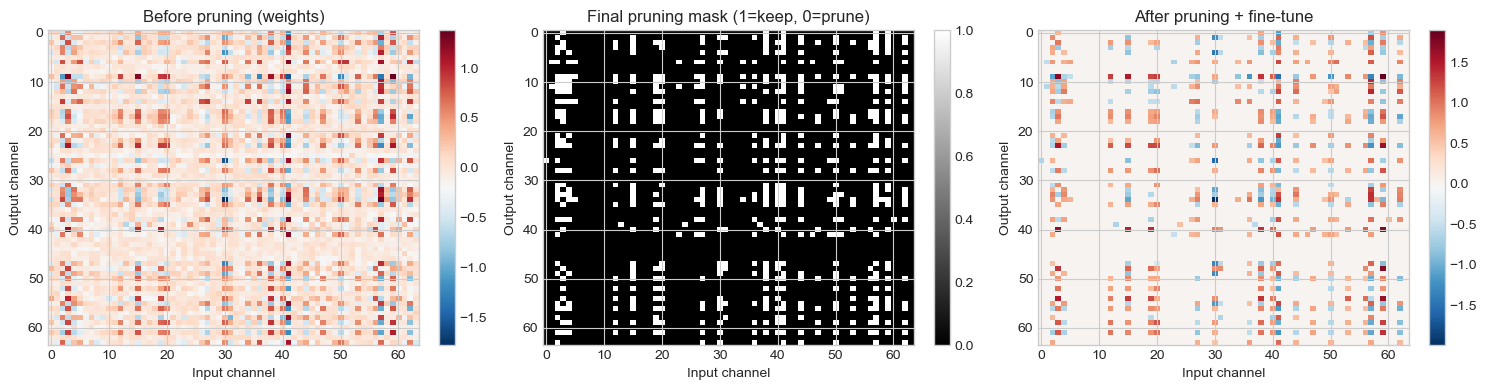

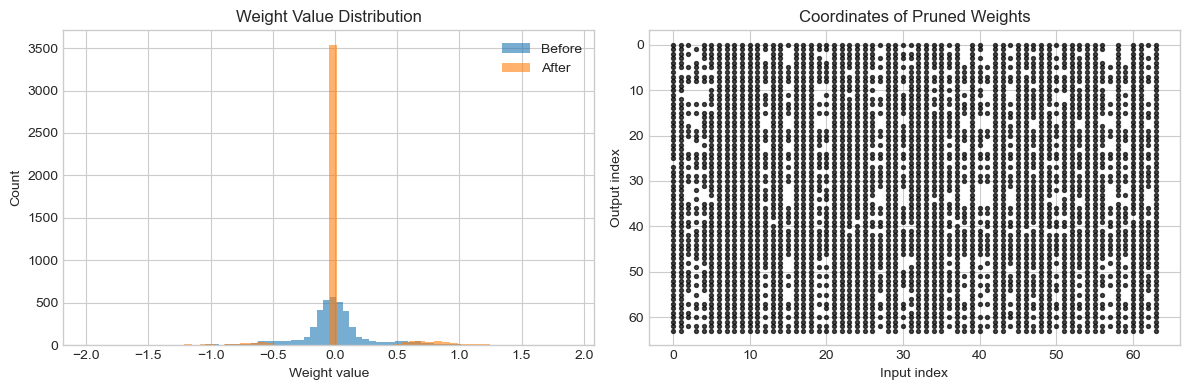

fc2 sparsity: 86.2%


In [8]:
layer_to_inspect = "fc2"

w_before = baseline_model.fc2.weight.detach().cpu().numpy()
w_after = iter_model.fc2.weight.detach().cpu().numpy()
mask_after = iter_masks[layer_to_inspect].detach().cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im0 = axes[0].imshow(w_before, cmap="RdBu_r", aspect="auto")
axes[0].set_title("Before pruning (weights)")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(mask_after, cmap="gray", aspect="auto")
axes[1].set_title("Final pruning mask (1=keep, 0=prune)")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(w_after, cmap="RdBu_r", aspect="auto")
axes[2].set_title("After pruning + fine-tune")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

for ax in axes:
    ax.set_xlabel("Input channel")
    ax.set_ylabel("Output channel")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(w_before.ravel(), bins=60, alpha=0.6, label="Before")
axes[0].hist(w_after.ravel(), bins=60, alpha=0.6, label="After")
axes[0].set_title("Weight Value Distribution")
axes[0].set_xlabel("Weight value")
axes[0].set_ylabel("Count")
axes[0].legend()

pruned_coords = np.argwhere(mask_after == 0)
if len(pruned_coords) > 0:
    axes[1].scatter(pruned_coords[:, 1], pruned_coords[:, 0], s=8, c="black", alpha=0.7)
axes[1].set_title("Coordinates of Pruned Weights")
axes[1].set_xlabel("Input index")
axes[1].set_ylabel("Output index")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"{layer_to_inspect} sparsity: {(1.0 - mask_after.mean()) * 100:.1f}%")


## 8. Quantization Intuition

Pruning removes connections. Quantization keeps connections but reduces precision.

For symmetric quantization, each float weight is mapped to an integer level and then de-quantized back to float during inference.

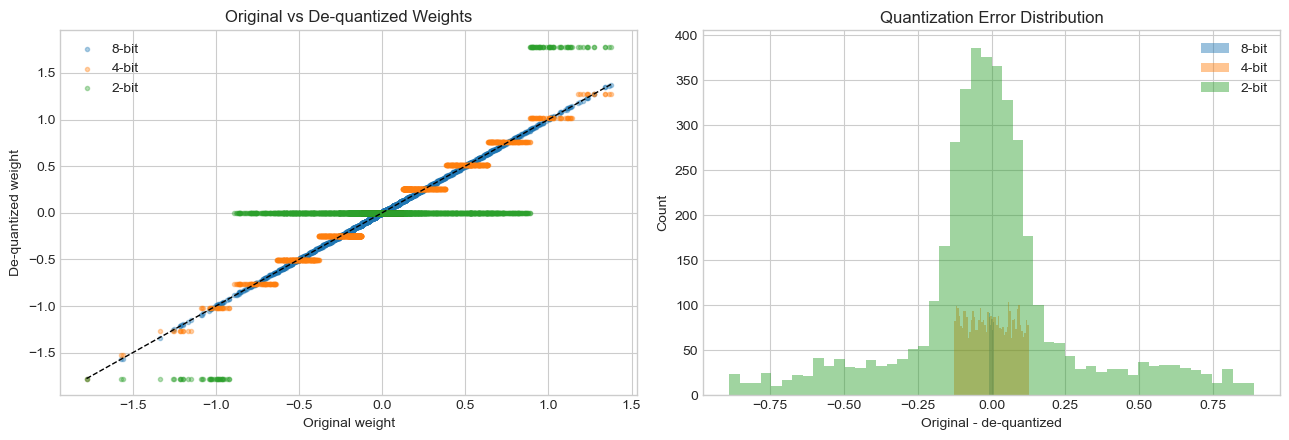

In [9]:
def quantize_tensor_symmetric(x, bits=8):
    if bits < 2:
        raise ValueError("bits must be >= 2")

    qmax = 2 ** (bits - 1) - 1
    max_abs = x.abs().max()

    if max_abs == 0:
        scale = torch.tensor(1.0, device=x.device, dtype=x.dtype)
    else:
        scale = max_abs / qmax

    q = torch.round(x / scale).clamp(-qmax, qmax)
    dq = q * scale
    return q, dq, scale


def quantize_model_weights(model, bits=8):
    q_model = copy.deepcopy(model).to(device)
    with torch.no_grad():
        for _, layer in linear_layers(q_model).items():
            _, dq_w, _ = quantize_tensor_symmetric(layer.weight.data, bits=bits)
            layer.weight.data.copy_(dq_w)

            if layer.bias is not None:
                _, dq_b, _ = quantize_tensor_symmetric(layer.bias.data, bits=bits)
                layer.bias.data.copy_(dq_b)

    return q_model


sample = baseline_model.fc2.weight.detach().flatten().cpu()
bits_demo = [8, 4, 2]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

x_np = sample.numpy()
for bits in bits_demo:
    _, dq, scale = quantize_tensor_symmetric(sample, bits=bits)
    dq_np = dq.numpy()

    axes[0].scatter(x_np, dq_np, s=9, alpha=0.35, label=f"{bits}-bit")
    err = x_np - dq_np
    axes[1].hist(err, bins=50, alpha=0.45, label=f"{bits}-bit")

axes[0].plot([x_np.min(), x_np.max()], [x_np.min(), x_np.max()], "k--", linewidth=1)
axes[0].set_title("Original vs De-quantized Weights")
axes[0].set_xlabel("Original weight")
axes[0].set_ylabel("De-quantized weight")
axes[0].legend()

axes[1].set_title("Quantization Error Distribution")
axes[1].set_xlabel("Original - de-quantized")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()


16-bit | test_acc=0.995 | theoretical dense memory ratio=0.500x
 8-bit | test_acc=0.995 | theoretical dense memory ratio=0.250x
 6-bit | test_acc=0.995 | theoretical dense memory ratio=0.188x
 4-bit | test_acc=0.995 | theoretical dense memory ratio=0.125x
 3-bit | test_acc=0.962 | theoretical dense memory ratio=0.094x
 2-bit | test_acc=0.657 | theoretical dense memory ratio=0.062x


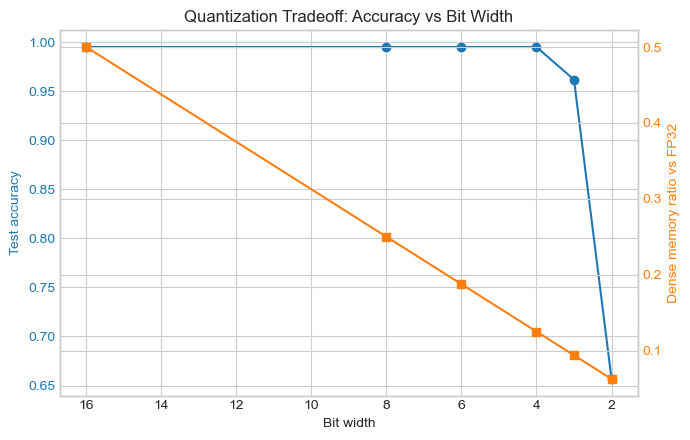

In [10]:
bit_widths = [16, 8, 6, 4, 3, 2]
quant_results = []

for bits in bit_widths:
    q_model = quantize_model_weights(baseline_model, bits=bits)
    _, acc = evaluate(q_model, test_loader)
    quant_results.append({
        "bits": bits,
        "test_acc": acc,
        "memory_ratio_vs_fp32": bits / 32.0
    })

for row in quant_results:
    print(
        f"{row['bits']:2d}-bit | test_acc={row['test_acc']:.3f} | "
        f"theoretical dense memory ratio={row['memory_ratio_vs_fp32']:.3f}x"
    )

fig, ax1 = plt.subplots(figsize=(7, 4.5))

bits = [r["bits"] for r in quant_results]
accs = [r["test_acc"] for r in quant_results]
mem = [r["memory_ratio_vs_fp32"] for r in quant_results]

ax1.plot(bits, accs, marker="o", color="tab:blue")
ax1.set_xlabel("Bit width")
ax1.set_ylabel("Test accuracy", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.set_title("Quantization Tradeoff: Accuracy vs Bit Width")

ax2 = ax1.twinx()
ax2.plot(bits, mem, marker="s", color="tab:orange")
ax2.set_ylabel("Dense memory ratio vs FP32", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

ax1.invert_xaxis()
plt.tight_layout()
plt.show()


## 9. Pruning + Quantization Together

Finally we compare four variants:
1. Baseline FP32
2. Iteratively pruned FP32
3. Baseline INT4
4. Pruned + INT4

We report accuracy and simple storage estimates for intuition.

Variant summary:
 Baseline FP32 | acc=0.995 | nonzero=1.000 | dense_mem_ratio=1.000 | ideal_sparse_ratio=1.000
   Pruned FP32 | acc=0.995 | nonzero=0.175 | dense_mem_ratio=1.000 | ideal_sparse_ratio=0.175
 Baseline INT4 | acc=0.995 | nonzero=0.457 | dense_mem_ratio=0.125 | ideal_sparse_ratio=0.057
 Pruned + INT4 | acc=0.995 | nonzero=0.171 | dense_mem_ratio=0.125 | ideal_sparse_ratio=0.021


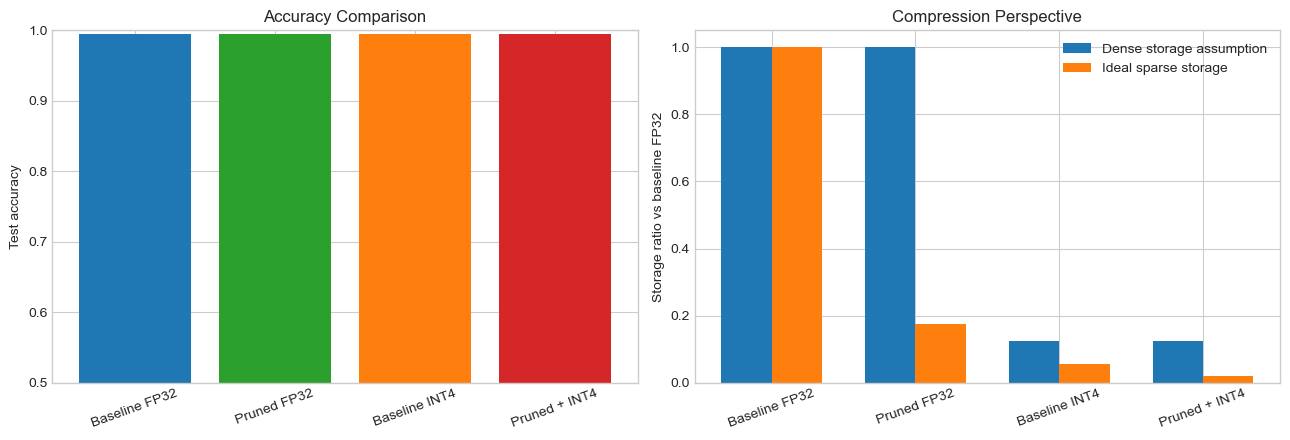

In [11]:
def count_total_and_nonzero_params(model):
    total = 0
    nonzero = 0
    for p in model.parameters():
        total += p.numel()
        nonzero += (p != 0).sum().item()
    return total, nonzero


q4_baseline = quantize_model_weights(baseline_model, bits=4)
q4_pruned = quantize_model_weights(iter_model, bits=4)

variants = {
    "Baseline FP32": baseline_model,
    "Pruned FP32": iter_model,
    "Baseline INT4": q4_baseline,
    "Pruned + INT4": q4_pruned,
}

summary = []
for name, model_v in variants.items():
    _, acc = evaluate(model_v, test_loader)
    total, nonzero = count_total_and_nonzero_params(model_v)
    nonzero_ratio = nonzero / total

    if "INT4" in name:
        dense_storage_ratio = 4 / 32
    else:
        dense_storage_ratio = 1.0

    sparse_storage_ratio = dense_storage_ratio * nonzero_ratio

    summary.append({
        "name": name,
        "acc": acc,
        "nonzero_ratio": nonzero_ratio,
        "dense_ratio": dense_storage_ratio,
        "sparse_ratio": sparse_storage_ratio,
    })

print("Variant summary:")
for row in summary:
    print(
        f"{row['name']:>14s} | acc={row['acc']:.3f} | "
        f"nonzero={row['nonzero_ratio']:.3f} | "
        f"dense_mem_ratio={row['dense_ratio']:.3f} | "
        f"ideal_sparse_ratio={row['sparse_ratio']:.3f}"
    )

labels = [r["name"] for r in summary]
accs = [r["acc"] for r in summary]
dense_mem = [r["dense_ratio"] for r in summary]
sparse_mem = [r["sparse_ratio"] for r in summary]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(labels, accs, color=["tab:blue", "tab:green", "tab:orange", "tab:red"])
axes[0].set_ylim(0.5, 1.0)
axes[0].set_ylabel("Test accuracy")
axes[0].set_title("Accuracy Comparison")
axes[0].tick_params(axis="x", rotation=20)

x = np.arange(len(labels))
width = 0.35
axes[1].bar(x - width / 2, dense_mem, width=width, label="Dense storage assumption")
axes[1].bar(x + width / 2, sparse_mem, width=width, label="Ideal sparse storage")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=20)
axes[1].set_ylabel("Storage ratio vs baseline FP32")
axes[1].set_title("Compression Perspective")
axes[1].legend()

plt.tight_layout()
plt.show()


## 10. Wrap-Up and Suggested Exercises

Key intuitions from this lab:
1. Different pruning criteria select different weights, even at the same sparsity.
2. Iterative prune-and-fine-tune usually preserves accuracy better than one-shot pruning.
3. Pruning is about **which connections to remove**, quantization is about **how precisely to store remaining values**.
4. Combining pruning and quantization often gives stronger compression than either alone.

Try these follow-up tasks:
1. Replace global pruning with layer-wise pruning and compare behavior.
2. Add simple quantization-aware training (fake quantization during training).
3. Repeat the experiment on a larger dataset or a CNN to inspect layer sensitivity.


## 11. Inference Speed Benchmark (Latency and Throughput)

This section measures actual inference speed for the final variants:
1. Baseline FP32
2. Pruned FP32
3. Baseline INT4 (de-quantized weights used in this notebook)
4. Pruned + INT4

We report:
- `pass_ms`: time to run the full test set once
- `sample_ms`: average latency per sample
- `throughput`: samples per second

Two batch regimes are benchmarked:
- `batch_size=1` (latency-sensitive)
- `batch_size=256` (throughput-oriented)


Device used for benchmark: cuda

Baseline FP32
    bs1 | pass_ms=45.748 | sample_ms=0.07625 | throughput=13115.3 samples/s | std_ms=7.876
  bs256 | pass_ms=0.350 | sample_ms=0.00058 | throughput=1712105.8 samples/s | std_ms=0.064

Pruned FP32
    bs1 | pass_ms=43.964 | sample_ms=0.07327 | throughput=13647.4 samples/s | std_ms=1.293
  bs256 | pass_ms=0.349 | sample_ms=0.00058 | throughput=1718576.0 samples/s | std_ms=0.050

Baseline INT4
    bs1 | pass_ms=65.580 | sample_ms=0.10930 | throughput=9149.2 samples/s | std_ms=3.569
  bs256 | pass_ms=0.471 | sample_ms=0.00079 | throughput=1273706.2 samples/s | std_ms=0.164

Pruned + INT4
    bs1 | pass_ms=49.391 | sample_ms=0.08232 | throughput=12148.0 samples/s | std_ms=1.842
  bs256 | pass_ms=0.370 | sample_ms=0.00062 | throughput=1619782.9 samples/s | std_ms=0.090

Relative speedup vs Baseline FP32
   Baseline FP32 | bs1=1.000x | bs256=1.000x
     Pruned FP32 | bs1=1.041x | bs256=1.004x
   Baseline INT4 | bs1=0.698x | bs256=0.744x
   Pruned

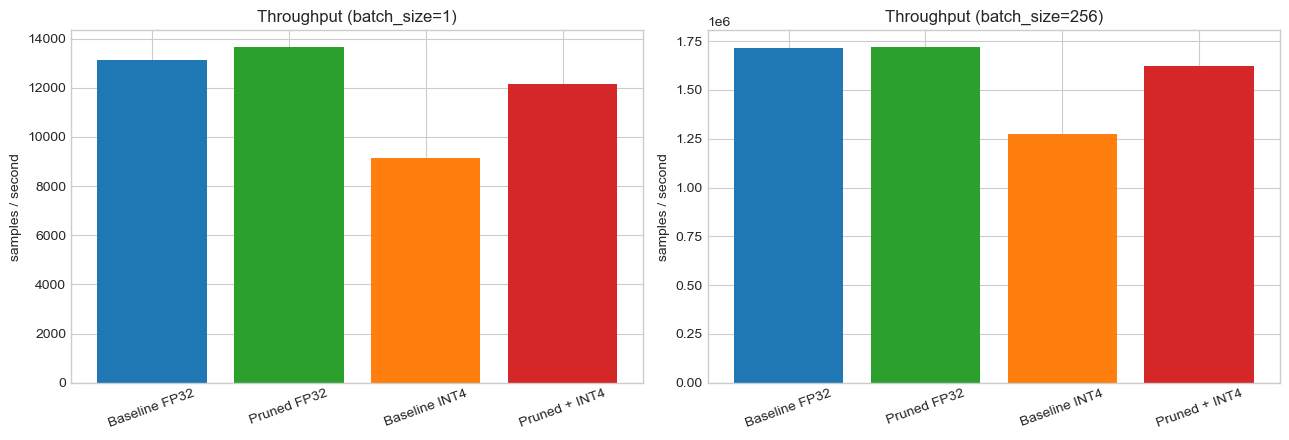

In [12]:
import time
import numpy as np

def benchmark_inference(model, x, batch_size=256, warmup=20, iters=120):
    model.eval()
    x = x.to(device)
    batches = [x[i:i + batch_size] for i in range(0, x.size(0), batch_size)]

    with torch.no_grad():
        # Warmup for more stable timing
        for _ in range(warmup):
            for b in batches:
                _ = model(b)

        times = []
        for _ in range(iters):
            t0 = time.perf_counter()
            for b in batches:
                _ = model(b)
            if device.type == 'cuda':
                torch.cuda.synchronize()
            t1 = time.perf_counter()
            times.append(t1 - t0)

    mean_s = float(np.mean(times))
    std_s = float(np.std(times))
    n = x.size(0)

    return {
        'mean_s': mean_s,
        'std_s': std_s,
        'pass_ms': mean_s * 1000,
        'sample_ms': (mean_s / n) * 1000,
        'throughput': n / mean_s,
    }

# `variants` is created in Section 9
speed_results = {}
for name, model_v in variants.items():
    speed_results[name] = {
        'bs1': benchmark_inference(model_v, X_test_t, batch_size=1, warmup=10, iters=80),
        'bs256': benchmark_inference(model_v, X_test_t, batch_size=256, warmup=20, iters=160),
    }

print(f"Device used for benchmark: {device}")
for name, rr in speed_results.items():
    print(f"\n{name}")
    for k in ['bs1', 'bs256']:
        m = rr[k]
        print(
            f"  {k:>5s} | pass_ms={m['pass_ms']:.3f} | sample_ms={m['sample_ms']:.5f} "
            f"| throughput={m['throughput']:.1f} samples/s | std_ms={m['std_s']*1000:.3f}"
        )

base_bs1 = speed_results['Baseline FP32']['bs1']['mean_s']
base_bs256 = speed_results['Baseline FP32']['bs256']['mean_s']

print("\nRelative speedup vs Baseline FP32")
for name, rr in speed_results.items():
    s1 = base_bs1 / rr['bs1']['mean_s']
    s256 = base_bs256 / rr['bs256']['mean_s']
    print(f"  {name:>14s} | bs1={s1:.3f}x | bs256={s256:.3f}x")

labels = list(speed_results.keys())
bs1_speed = [speed_results[k]['bs1']['throughput'] for k in labels]
bs256_speed = [speed_results[k]['bs256']['throughput'] for k in labels]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(labels, bs1_speed, color=['tab:blue', 'tab:green', 'tab:orange', 'tab:red'])
axes[0].set_title('Throughput (batch_size=1)')
axes[0].set_ylabel('samples / second')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(labels, bs256_speed, color=['tab:blue', 'tab:green', 'tab:orange', 'tab:red'])
axes[1].set_title('Throughput (batch_size=256)')
axes[1].set_ylabel('samples / second')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()
